# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [15]:
pip install palmerpenguins

In [58]:
# Code Here
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from palmerpenguins import load_penguins

penguins_df = load_penguins()
penguins_df.dropna(inplace=True)
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [17]:
dummies = pd.get_dummies(penguins_df)*1
dummies.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,39.1,18.7,181.0,3750.0,2007,1,0,0,0,0,1,0,1
1,39.5,17.4,186.0,3800.0,2007,1,0,0,0,0,1,1,0
2,40.3,18.0,195.0,3250.0,2007,1,0,0,0,0,1,1,0
4,36.7,19.3,193.0,3450.0,2007,1,0,0,0,0,1,1,0
5,39.3,20.6,190.0,3650.0,2007,1,0,0,0,0,1,0,1


Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on a training dataset subset of the entire dataset:

* Four different models, each containing a different set of predictor variables

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

In [44]:
# Code Here
# Model 1 with just bill_length_mm as a predictor
X_train1 = dummies[["bill_length_mm"]]
y_train = dummies["bill_depth_mm"]

Model1 = LinearRegression()
Model1.fit(
    X=X_train1,
    y=y_train
)

LinearRegression()

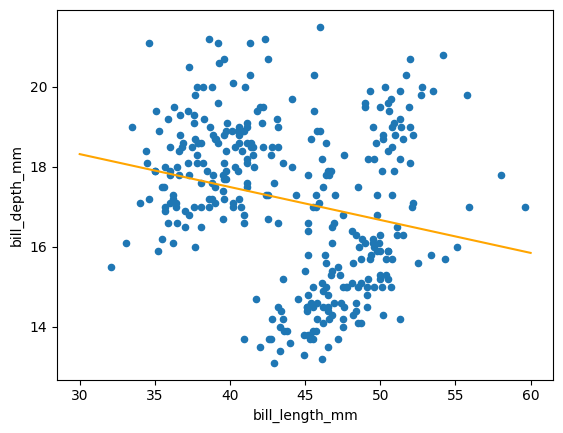

In [45]:
X_new = pd.DataFrame()
X_new["bill_length_mm"] = np.linspace(30, 60, num=1000)
y_new_ = pd.Series(
    Model1.predict(X_new),
    index=X_new["bill_length_mm"]
)

dummies.plot.scatter(x="bill_length_mm", y="bill_depth_mm")
y_new_.plot.line(c = "orange");

In [46]:
y_train_1 = Model1.predict(X=X_train1)
dummies["Model1_predict"] = y_train_1

In [47]:
# Model 2 with bill_length_mm and flipper_length_mm
X_train2 = dummies[["bill_length_mm", "flipper_length_mm"]]
y_train = dummies["bill_depth_mm"]

Model2 = LinearRegression()
Model2.fit(
    X=X_train2,
    y=y_train
)

LinearRegression()

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

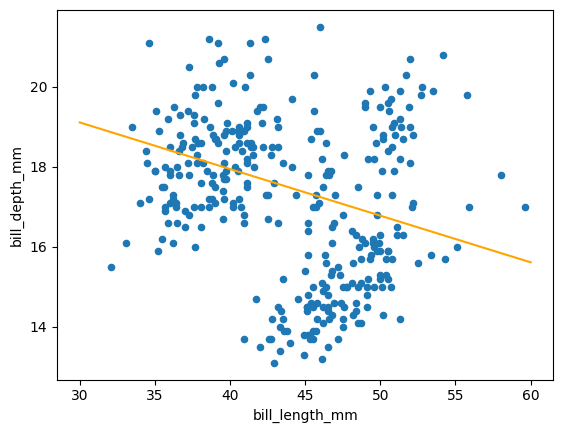

In [48]:
X_new = pd.DataFrame()
X_new["bill_length_mm"] = np.linspace(30, 60, num=1000)
X_new["flipper_length_mm"] = np.linspace(170, 230, num=1000)
y_new_ = pd.Series(
    Model2.predict(X_new),
    index=X_new["bill_length_mm"]
)

dummies.plot.scatter(x="bill_length_mm", y="bill_depth_mm")
y_new_.plot.line(c = "orange")

In [49]:
y_train_2 = Model2.predict(X=X_train2)
dummies["Model2_predict"] = y_train_2

In [50]:
# Model 3 with bill_length_mm, flipper_length_mm, and body_mass_g
X_train3 = dummies[["bill_length_mm", "flipper_length_mm", "body_mass_g"]]
y_train = dummies["bill_depth_mm"]

Model3 = LinearRegression()
Model3.fit(
    X=X_train3,
    y=y_train
)

LinearRegression()

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

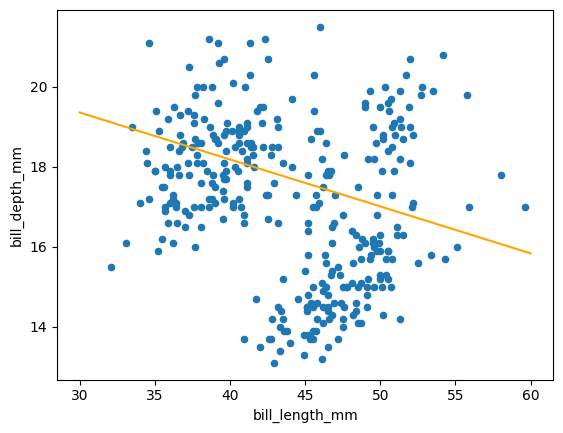

In [51]:
X_new = pd.DataFrame()
X_new["bill_length_mm"] = np.linspace(30, 60, num=1000)
X_new["flipper_length_mm"] = np.linspace(170, 230, num=1000)
X_new["body_mass_g"] = np.linspace(3500, 6500, num=1000)
y_new_ = pd.Series(
    Model3.predict(X_new),
    index=X_new["bill_length_mm"]
)

dummies.plot.scatter(x="bill_length_mm", y="bill_depth_mm")
y_new_.plot.line(c = "orange")

In [52]:
y_train_3 = Model3.predict(X=X_train3)
dummies["Model3_predict"] = y_train_3

In [53]:
# Model 4 with bill_length_mm, flipper_length_mm, body_mass_g, and sex_male
X_train4 = dummies[["bill_length_mm", "flipper_length_mm", "body_mass_g","sex_male"]]
y_train = dummies["bill_depth_mm"]

Model4 = LinearRegression()
Model4.fit(
    X=X_train4,
    y=y_train
)

LinearRegression()

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

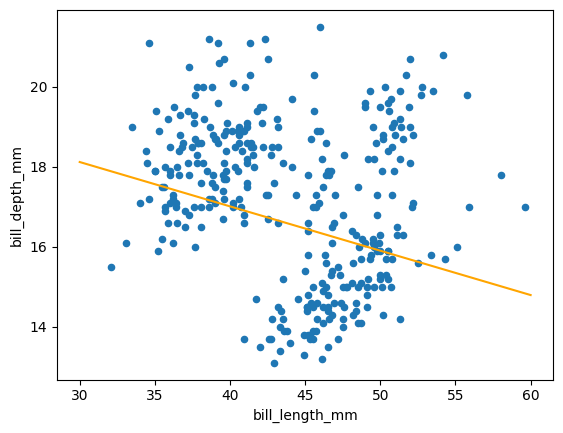

In [54]:
X_new = pd.DataFrame()
X_new["bill_length_mm"] = np.linspace(30, 60, num=1000)
X_new["flipper_length_mm"] = np.linspace(170, 230, num=1000)
X_new["body_mass_g"] = np.linspace(3500, 6500, num=1000)
X_new["sex_male"] = np.linspace(0, 1, num=1000)
y_new_ = pd.Series(
    Model4.predict(X_new),
    index=X_new["bill_length_mm"]
)

dummies.plot.scatter(x="bill_length_mm", y="bill_depth_mm")
y_new_.plot.line(c = "orange")

In [55]:
y_train_4 = Model4.predict(X=X_train4)
dummies["Model4_predict"] = y_train_4

In [61]:
X_train, X_test, y_train, y_test = train_test_split(dummies.drop(['bill_depth_mm'], axis=1), dummies['bill_depth_mm'], test_size=0.25)

In [65]:
predictor_sets = [
    ["bill_length_mm"],
    ["bill_length_mm", "flipper_length_mm"],
    ["bill_length_mm", "flipper_length_mm", "body_mass_g"],
    ["bill_length_mm", "flipper_length_mm", "body_mass_g", "sex_male"]]

In [66]:
train_rmse, test_rmse = [], []

for predictors in predictor_sets:
    model = LinearRegression()
    model.fit(X_train[predictors], y_train)

    y_train_pred = model.predict(X_train[predictors])
    y_test_pred = model.predict(X_test[predictors])

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_rmse.append(rmse_train)
    test_rmse.append(rmse_test)
rmse_df = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3', 'Model 4'],
    'Train RMSE': train_rmse,
    'Test RMSE': test_rmse
})
rmse_df

,Model,Train RMSE,Test RMSE
0,Model 1,1.903096,1.959235
1,Model 2,1.579887,1.504193
2,Model 3,1.577962,1.496948
3,Model 4,1.206844,0.959774


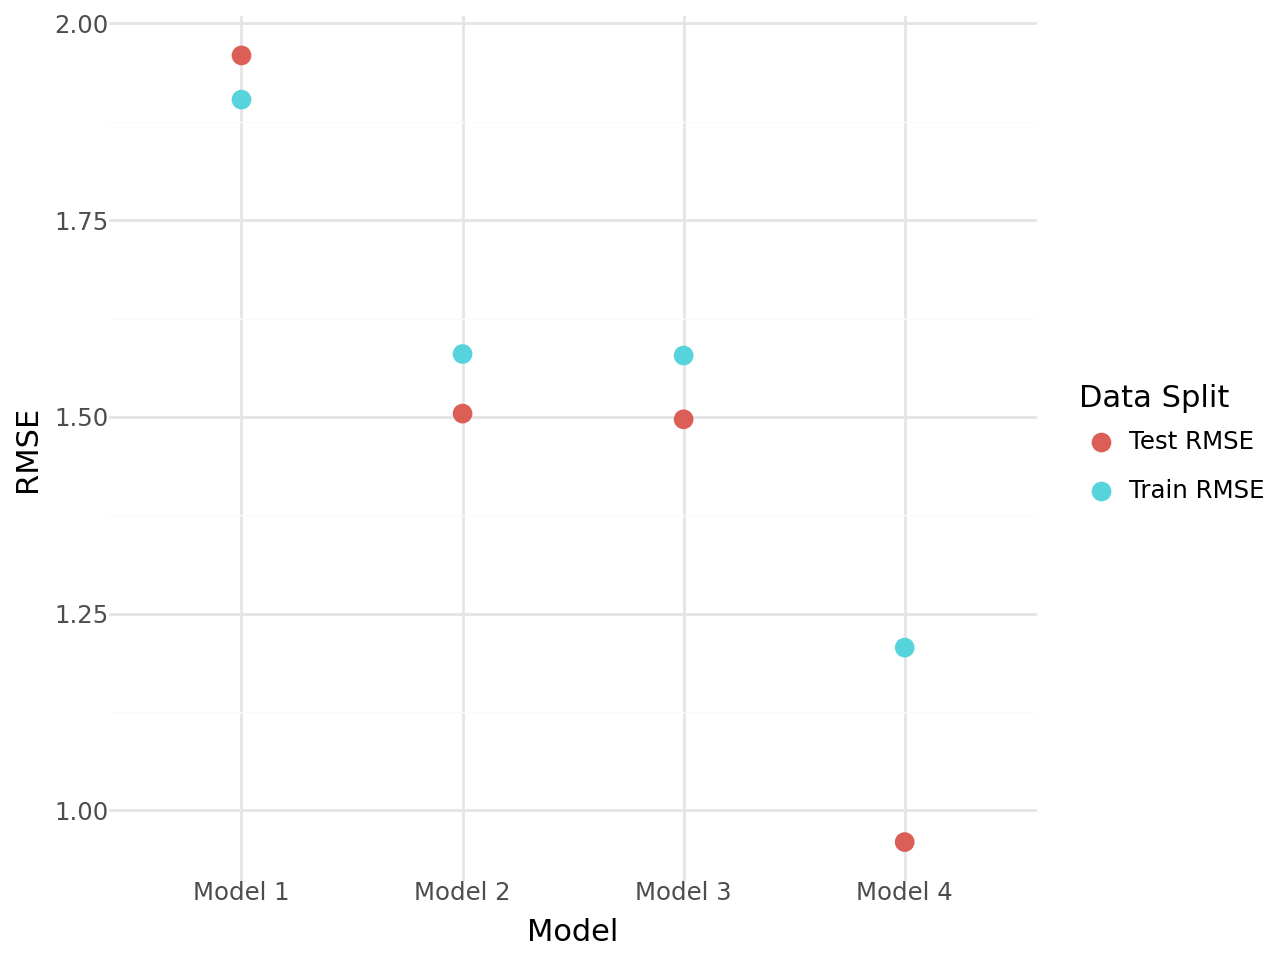

In [68]:
from plotnine import ggplot, aes, geom_point, labs, theme_minimal
rmse_long = rmse_df.melt(id_vars='Model', var_name='Set', value_name='RMSE')

(
    ggplot(rmse_long, aes(x='Model', y='RMSE', color='Set', group='Set'))
    + geom_point(size=3)
    + theme_minimal()
    + labs(x="Model", y="RMSE", color="Data Split")
)